# Drive Model Test & Debug
휠 동역학 모델 테스트 및 디버깅 노트북

## 목적
- DriveModel과 BrakeModel 통합 동작 확인
- **입력**: T_Drv, T_brk, F_x → **출력**: ω_wheel 응답 검증
- 회전 동역학 방정식: `J*dω/dt = T_Drv - R*F_x - F_clamp`

In [1]:
# 필요한 라이브러리 import
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 프로젝트 루트를 Python path에 추가
project_root = Path.cwd().parent.parent.parent.parent.parent
sys.path.insert(0, str(project_root))

# DriveModel과 BrakeModel import
from vehicle_sim.models.e_corner.drive.drive_model import DriveModel
from vehicle_sim.models.e_corner.drive.brake_model import BrakeModel

print("Import 성공!")

Import 성공!


## 1. 기본 동작 테스트
DriveModel과 BrakeModel 생성 및 기본 파라미터 확인

In [2]:
# 모델 생성
drive = DriveModel()
brake = BrakeModel()

print("=== Drive Model Parameters ===")
print(f"휠 관성 클램핑력 J_wheel: {drive.params.J_wheel} kg·m²")
print(f"휠 반지름 R_wheel: {drive.params.R_wheel} m")
print(f"최대 휠 각속도 max_wheel_speed: {drive.params.max_wheel_speed} rad/s")

print("\n=== Brake Model Parameters ===")
print(f"시간 상수 tau: {brake.params.tau} s")

print("\n=== 초기 상태 ===")
print(f"Drive 상태: {drive.get_state()}")
print(f"Brake 상태: {brake.get_state()}")


=== Drive Model Parameters ===
휠 관성 클램핑력 J_wheel: 0.5 kg·m²
휠 반지름 R_wheel: 0.321 m
최대 휠 각속도 max_wheel_speed: 60.63 rad/s

=== Brake Model Parameters ===
시간 상수 tau: 0.1 s

=== 초기 상태 ===
Drive 상태: {'wheel_speed': 0.0}
Brake 상태: {'clamp_force': 0.0}


## 2. 시계열 응답 테스트 - 가속 시나리오
**입력**: T_Drv (스텝), T_brk=0, F_x (속도 비례 저항)  
**출력**: ω_wheel

In [3]:
# 시뮬레이션 설정
dt = 0.001
t_end = 5.0
time_steps = int(t_end / dt)
time = np.arange(0, t_end, dt)

# 데이터 저장 배열
omega_history = np.zeros(time_steps)
T_Drv_history = np.zeros(time_steps)
F_x_history = np.zeros(time_steps)
F_clamp_history = np.zeros(time_steps)

# 모델 리셋
drive.reset()
brake.reset()

# 시뮬레이션 실행
F_x = 0.0

for i in range(time_steps):
    t = time[i]
    
    # [입력] 일정한 구동 토크, 브레이크 없음
    T_Drv = 100.0 if t < 3.0 else 0.0
    T_brk = 0.0
    
    # [입력] 타이어 힘 (임의): 속도에 비례하는 저항
    F_x = 10.0 * omega_history[i-1] if i > 0 else 0.0
    
    # 업데이트
    F_clamp = brake.update(dt, T_brk)
    omega = drive.update(dt, T_Drv, F_clamp, F_x)
    
    # 저장
    omega_history[i] = omega
    T_Drv_history[i] = T_Drv
    F_x_history[i] = F_x
    F_clamp_history[i] = F_clamp

print("가속 시뮬레이션 완료!")
print(f"최종 휠 각속도: {omega_history[-1]:.2f} rad/s")

가속 시뮬레이션 완료!
최종 휠 각속도: 11.29 rad/s


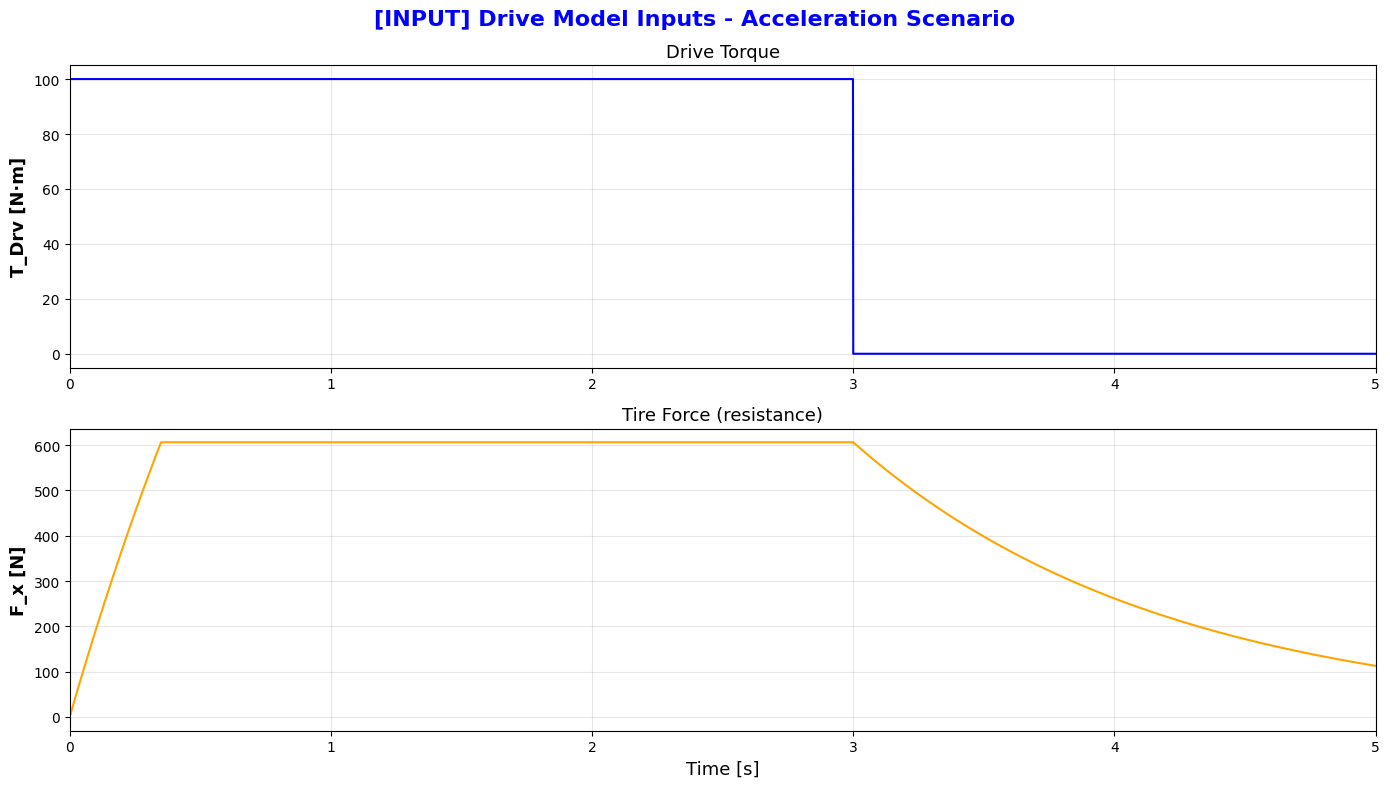

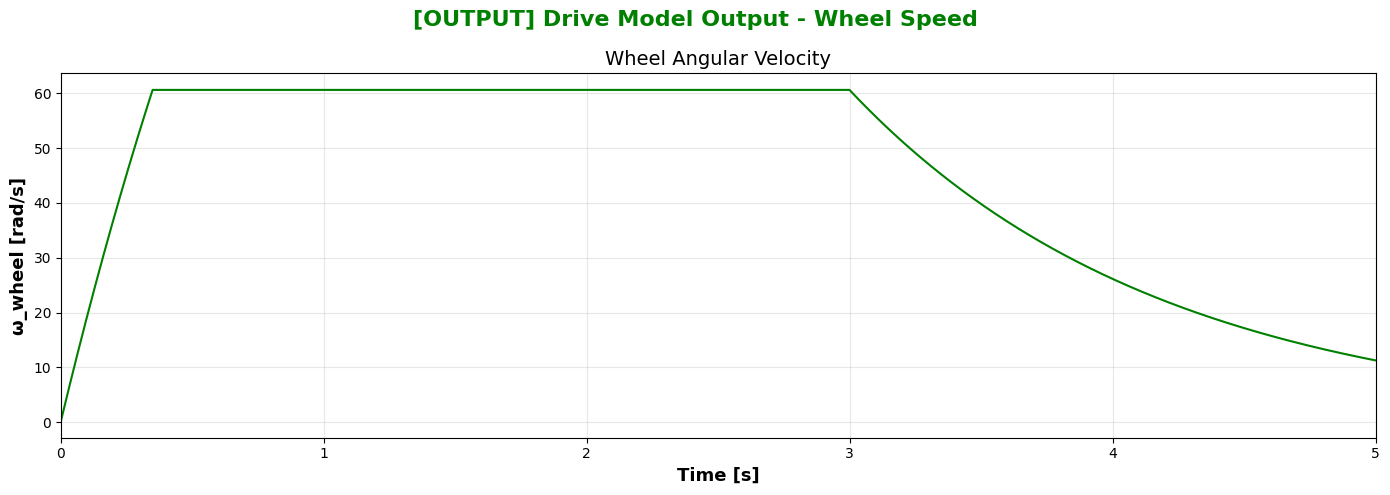

In [4]:
# ========================================
# [입력 INPUT] 시각화 - 가속 시나리오
# ========================================
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('[INPUT] Drive Model Inputs - Acceleration Scenario', fontsize=16, fontweight='bold', color='blue')

# 입력 1: 구동 토크
axes[0].plot(time, T_Drv_history, 'b-', linewidth=1.5)
axes[0].set_ylabel('T_Drv [N·m]', fontsize=13, fontweight='bold')
axes[0].set_title('Drive Torque', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, t_end])

# 입력 2: 타이어 힘
axes[1].plot(time, F_x_history, 'orange', linewidth=1.5)
axes[1].set_xlabel('Time [s]', fontsize=13)
axes[1].set_ylabel('F_x [N]', fontsize=13, fontweight='bold')
axes[1].set_title('Tire Force (resistance)', fontsize=13)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, t_end])

plt.tight_layout()
plt.show()

# ========================================
# [출력 OUTPUT] 시각화
# ========================================
fig, ax = plt.subplots(1, 1, figsize=(14, 5))
fig.suptitle('[OUTPUT] Drive Model Output - Wheel Speed', fontsize=16, fontweight='bold', color='green')

# 출력: 휠 각속도
ax.plot(time, omega_history, 'g-', linewidth=1.5)
ax.set_xlabel('Time [s]', fontsize=13, fontweight='bold')
ax.set_ylabel('ω_wheel [rad/s]', fontsize=13, fontweight='bold')
ax.set_title('Wheel Angular Velocity', fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, t_end])

plt.tight_layout()
plt.show()

## 3. 제동 시나리오
**입력**: T_Drv, T_brk (3단계 변화), F_x  
**출력**: ω_wheel

In [5]:
# 시뮬레이션 설정
dt = 0.001
t_end = 8.0
time_steps = int(t_end / dt)
time = np.arange(0, t_end, dt)

# 데이터 저장
omega_history = np.zeros(time_steps)
T_Drv_history = np.zeros(time_steps)
T_brk_history = np.zeros(time_steps)
F_clamp_history = np.zeros(time_steps)
F_x_history = np.zeros(time_steps)

# 모델 리셋
drive.reset()
brake.reset()

# 시뮬레이션
F_x = 0.0

for i in range(time_steps):
    t = time[i]
    
    # [입력] 시나리오: 0-3초 가속, 3-5초 타력, 5-8초 제동
    if t < 3.0:
        T_Drv = 150.0
        T_brk = 0.0
    elif t < 5.0:
        T_Drv = 0.0
        T_brk = 0.0
    else:
        T_Drv = 0.0
        T_brk = 100.0
    
    # [입력] 타이어 힘 (속도 비례 저항)
    F_x = 15.0 * omega_history[i-1] if i > 0 else 0.0
    
    # 업데이트 (전진 방향: direction=1)
    F_clamp = brake.update(dt, T_brk)
    omega = drive.update(dt, T_Drv, F_clamp, F_x, direction=1)
    
    # 저장
    omega_history[i] = omega
    T_Drv_history[i] = T_Drv
    T_brk_history[i] = T_brk
    F_clamp_history[i] = F_clamp
    F_x_history[i] = F_x

print("제동 시뮬레이션 완료!")
print(f"최종 휠 각속도: {omega_history[-1]:.2f} rad/s")

제동 시뮬레이션 완료!
최종 휠 각속도: -60.63 rad/s


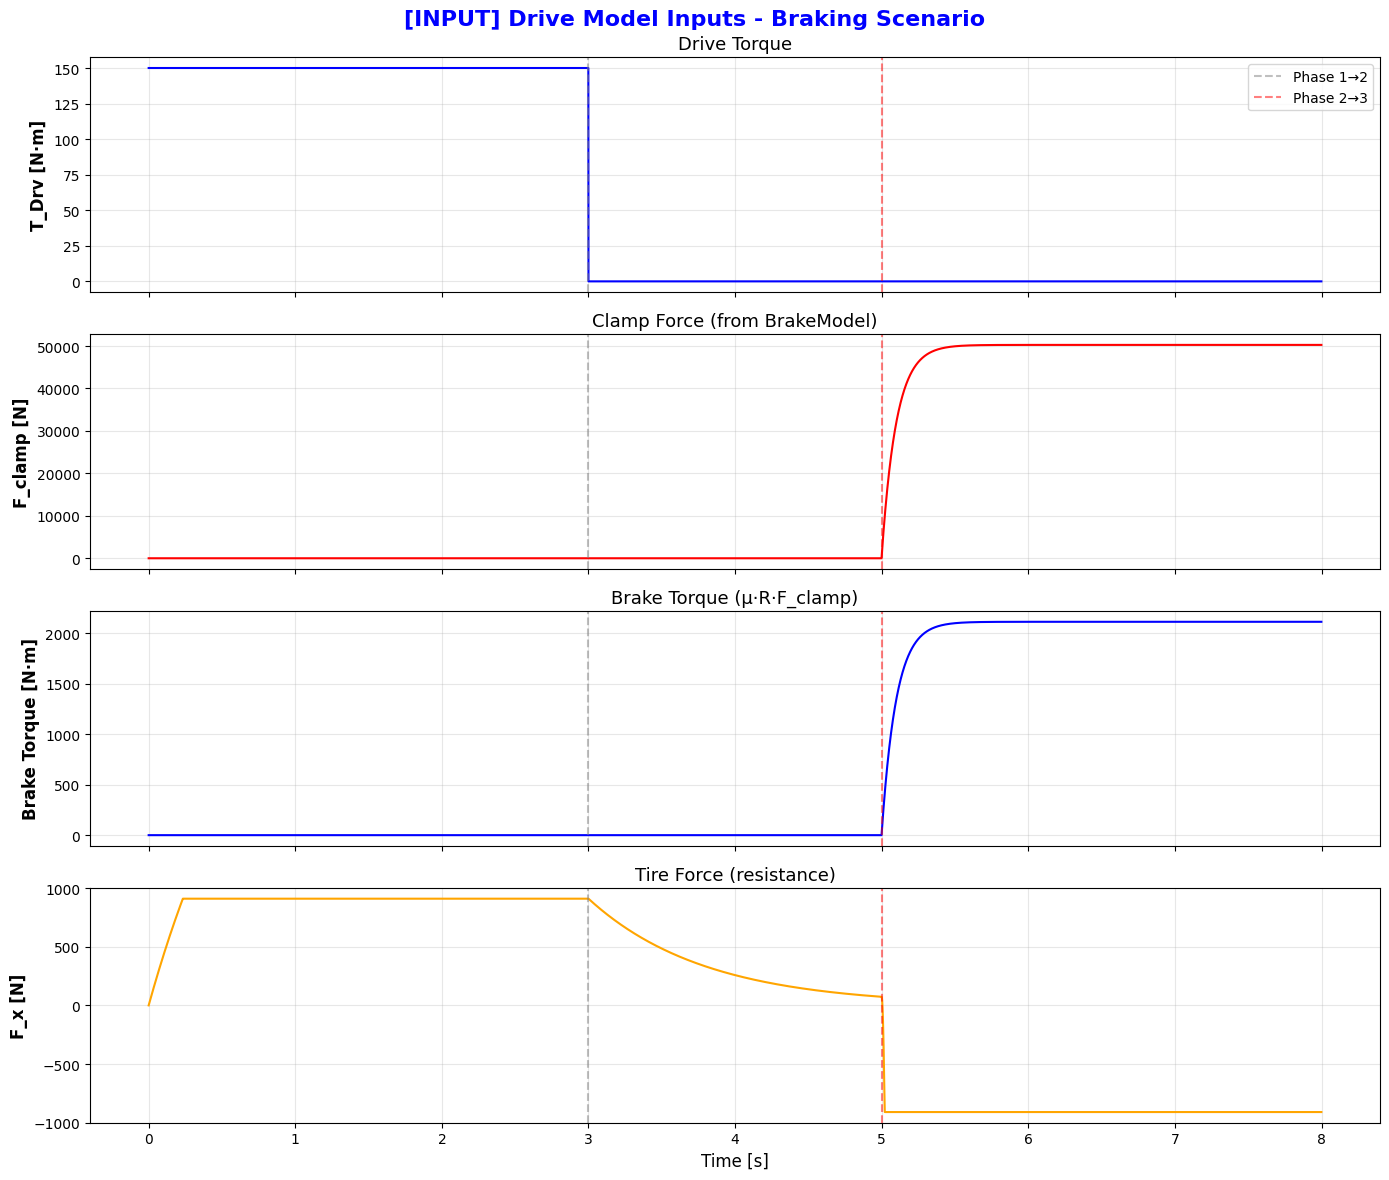

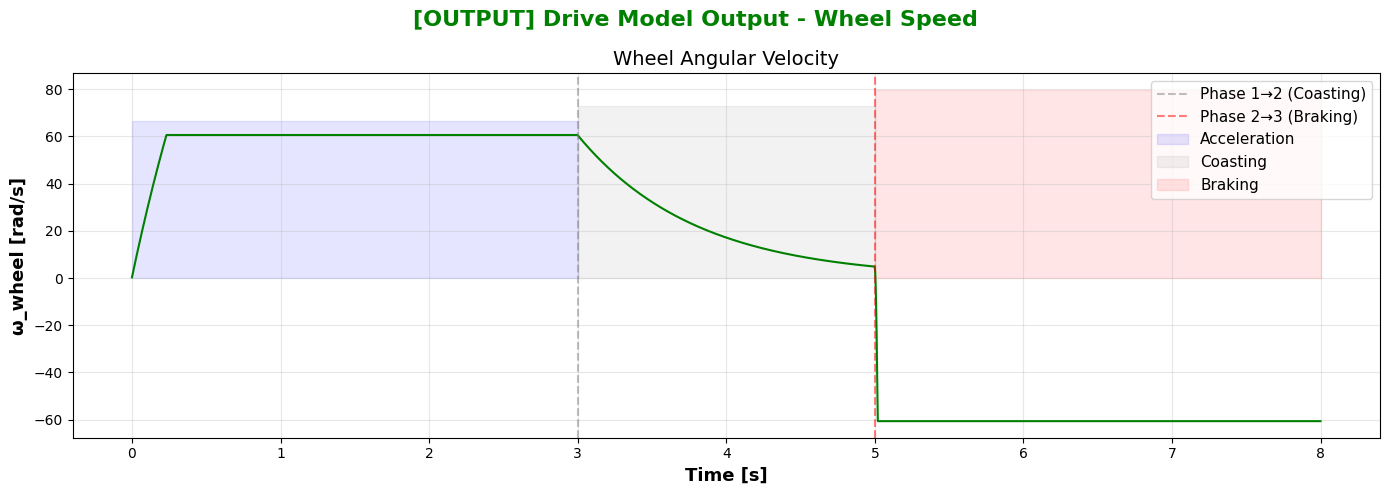

In [6]:
# ========================================
# [입력 INPUT] 시각화 - 제동 시나리오
# ========================================
try:
    drive_plot = DriveModel()
    torque_gain = drive_plot.brake_params.mu_pad * drive_plot.brake_params.R_rotor
except Exception as e:
    print('DriveModel 로드 실패, 기본값 사용', e)
    torque_gain = 0.35 * 0.16

if 'time' in globals() and 'T_Drv_history' in globals() and 'F_clamp_history' in globals() and 'F_x_history' in globals():
    n = min(len(time), len(T_Drv_history), len(F_clamp_history), len(F_x_history))
    time_plot = time[:n]
    T_Drv_plot = T_Drv_history[:n]
    F_clamp_plot = F_clamp_history[:n]
    F_x_plot = F_x_history[:n]
    M_brk_plot = F_clamp_plot * torque_gain

    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
    fig.suptitle('[INPUT] Drive Model Inputs - Braking Scenario', fontsize=16, fontweight='bold', color='blue')
    # 입력 1: 구동 토크
    axes[0].plot(time_plot, T_Drv_plot, 'b-', linewidth=1.5)
    axes[0].set_ylabel('T_Drv [N·m]', fontsize=12, fontweight='bold')
    axes[0].set_title('Drive Torque', fontsize=13)
    axes[0].grid(True, alpha=0.3)
    axes[0].axvline(x=3.0, color='gray', linestyle='--', alpha=0.5, label='Phase 1→2')
    axes[0].axvline(x=5.0, color='red', linestyle='--', alpha=0.5, label='Phase 2→3')
    axes[0].legend(fontsize=10)
    # 입력 2: 클램핑력
    axes[1].plot(time_plot, F_clamp_plot, 'r-', linewidth=1.5)
    axes[1].set_ylabel('F_clamp [N]', fontsize=12, fontweight='bold')
    axes[1].set_title('Clamp Force (from BrakeModel)', fontsize=13)
    axes[1].grid(True, alpha=0.3)
    axes[1].axvline(x=3.0, color='gray', linestyle='--', alpha=0.5)
    axes[1].axvline(x=5.0, color='red', linestyle='--', alpha=0.5)
    # 입력 3: 환산 브레이크 토크
    axes[2].plot(time_plot, M_brk_plot, 'b-', linewidth=1.5)
    axes[2].set_ylabel('Brake Torque [N·m]', fontsize=12, fontweight='bold')
    axes[2].set_title('Brake Torque (μ·R·F_clamp)', fontsize=13)
    axes[2].grid(True, alpha=0.3)
    axes[2].axvline(x=3.0, color='gray', linestyle='--', alpha=0.5)
    axes[2].axvline(x=5.0, color='red', linestyle='--', alpha=0.5)
    # 입력 4: 타이어 힘
    axes[3].plot(time_plot, F_x_plot, 'orange', linewidth=1.5)
    axes[3].set_xlabel('Time [s]', fontsize=12)
    axes[3].set_ylabel('F_x [N]', fontsize=12, fontweight='bold')
    axes[3].set_title('Tire Force (resistance)', fontsize=13)
    axes[3].grid(True, alpha=0.3)
    axes[3].axvline(x=3.0, color='gray', linestyle='--', alpha=0.5)
    axes[3].axvline(x=5.0, color='red', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print('제동 시나리오 데이터(time, T_Drv_history, F_clamp_history, F_x_history)를 먼저 생성하세요.')

# ========================================
# [출력 OUTPUT] 시각화
# ========================================
fig, ax = plt.subplots(1, 1, figsize=(14, 5))
fig.suptitle('[OUTPUT] Drive Model Output - Wheel Speed', fontsize=16, fontweight='bold', color='green')
ax.plot(time, omega_history, 'g-', linewidth=1.5)
ax.set_xlabel('Time [s]', fontsize=13, fontweight='bold')
ax.set_ylabel('ω_wheel [rad/s]', fontsize=13, fontweight='bold')
ax.set_title('Wheel Angular Velocity', fontsize=14)
ax.grid(True, alpha=0.3)
ax.axvline(x=3.0, color='gray', linestyle='--', alpha=0.5, linewidth=1.5, label='Phase 1→2 (Coasting)')
ax.axvline(x=5.0, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='Phase 2→3 (Braking)')
ax.fill_between([0, 3], 0, ax.get_ylim()[1], alpha=0.1, color='blue', label='Acceleration')
ax.fill_between([3, 5], 0, ax.get_ylim()[1], alpha=0.1, color='gray', label='Coasting')
ax.fill_between([5, 8], 0, ax.get_ylim()[1], alpha=0.1, color='red', label='Braking')
ax.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()


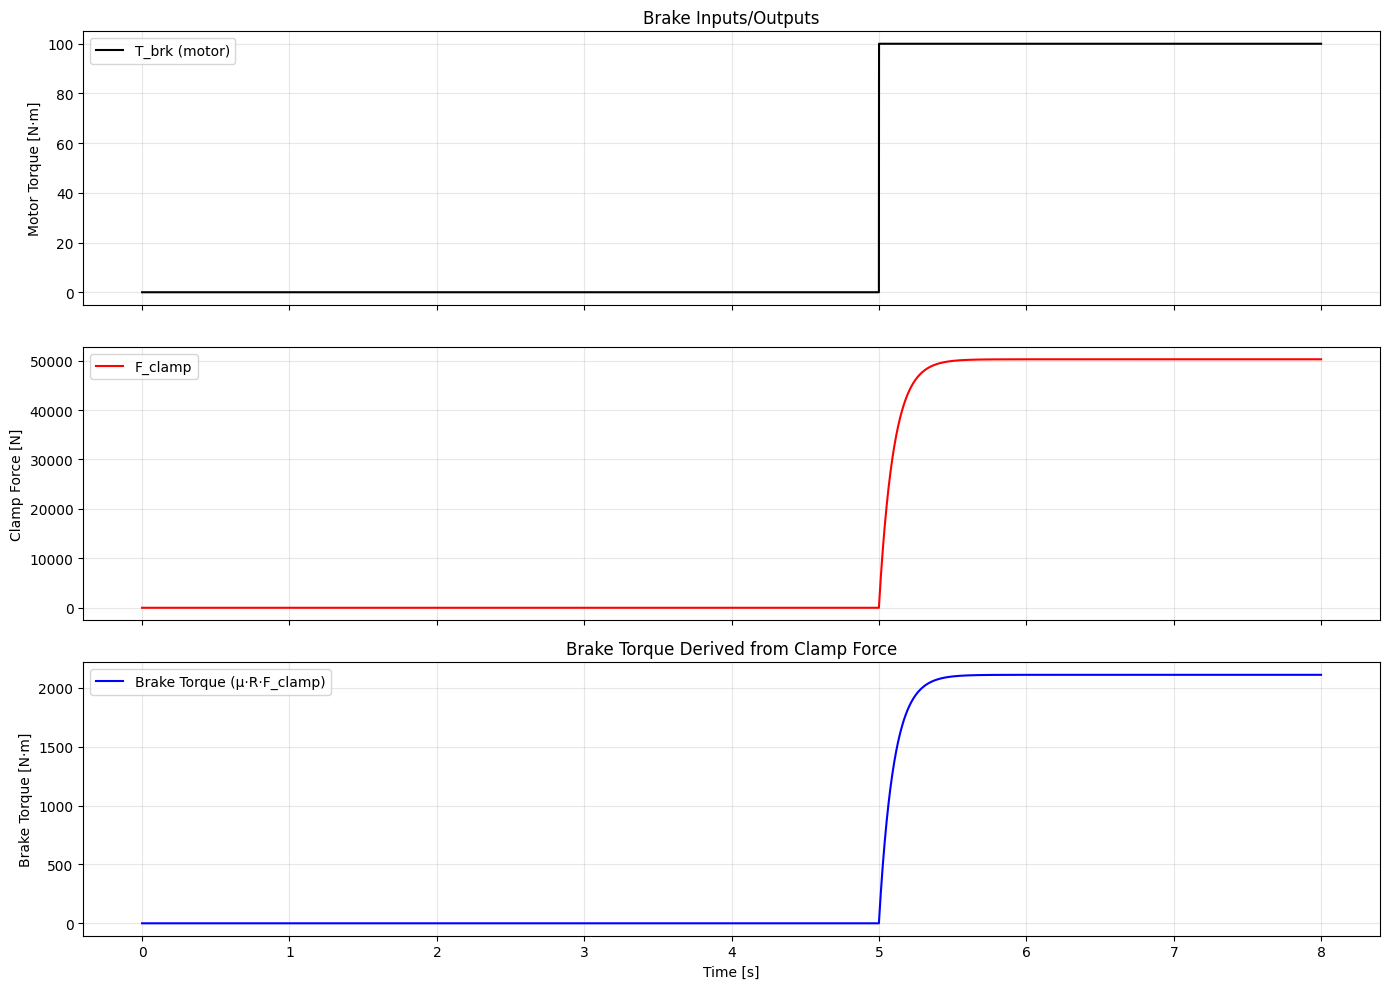

In [7]:
# 클램핑력 → 제동 토크 추가 시각화
try:
    drive_plot = DriveModel()
    torque_gain = drive_plot.brake_params.mu_pad * drive_plot.brake_params.R_rotor
except Exception as e:
    print('DriveModel 로드 실패, 기본값 사용', e)
    torque_gain = 0.35 * 0.16

if 'F_clamp_history' in globals() and 'time' in globals() and 'T_brk_history' in globals():
    n = min(len(time), len(F_clamp_history), len(T_brk_history))
    time_plot = time[:n]
    F_clamp_plot = F_clamp_history[:n]
    T_brk_plot = T_brk_history[:n]
    M_brk_plot = F_clamp_plot * torque_gain
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    axes[0].plot(time_plot, T_brk_plot, 'k-', linewidth=1.5, label='T_brk (motor)')
    axes[0].set_ylabel('Motor Torque [N·m]')
    axes[0].set_title('Brake Inputs/Outputs')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(time_plot, F_clamp_plot, 'r-', linewidth=1.5, label='F_clamp')
    axes[1].set_ylabel('Clamp Force [N]')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    axes[2].plot(time_plot, M_brk_plot, 'b-', linewidth=1.5, label='Brake Torque (μ·R·F_clamp)')
    axes[2].set_xlabel('Time [s]')
    axes[2].set_ylabel('Brake Torque [N·m]')
    axes[2].set_title('Brake Torque Derived from Clamp Force')
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    plt.tight_layout()
    plt.show()
else:
    print('제동 시나리오 데이터를 먼저 실행하세요 (time/T_brk_history/F_clamp_history).')


## 4. 파라미터 변화 테스트
**입력**: T_Drv (스텝), 다양한 J_wheel 값  
**출력**: ω_wheel (J에 따른 응답 비교)

In [8]:
# 다양한 J 값 테스트
J_values = [0.2, 0.5, 1.0, 2.0]
dt = 0.001
t_end = 5.0
time_steps = int(t_end / dt)
time = np.arange(0, t_end, dt)

# 입력: 스텝 토크
T_Drv_input = np.where(time < 2.5, 0.0, 100.0)

results_J = {}

for J in J_values:
    drive_test = DriveModel()
    brake_test = BrakeModel()
    drive_test.params.J_wheel = J
    
    omega_output = np.zeros(time_steps)
    F_x = 0.0
    
    for i in range(time_steps):
        T_Drv = T_Drv_input[i]
        F_clamp = brake_test.update(dt, 0.0)
        F_x = 10.0 * omega_output[i-1] if i > 0 else 0.0
        omega_output[i] = drive_test.update(dt, T_Drv, F_clamp, F_x)
    
    results_J[J] = omega_output

print(f"관성 클램핑력 변화 테스트 완료! 테스트한 J 값: {J_values}")

관성 클램핑력 변화 테스트 완료! 테스트한 J 값: [0.2, 0.5, 1.0, 2.0]


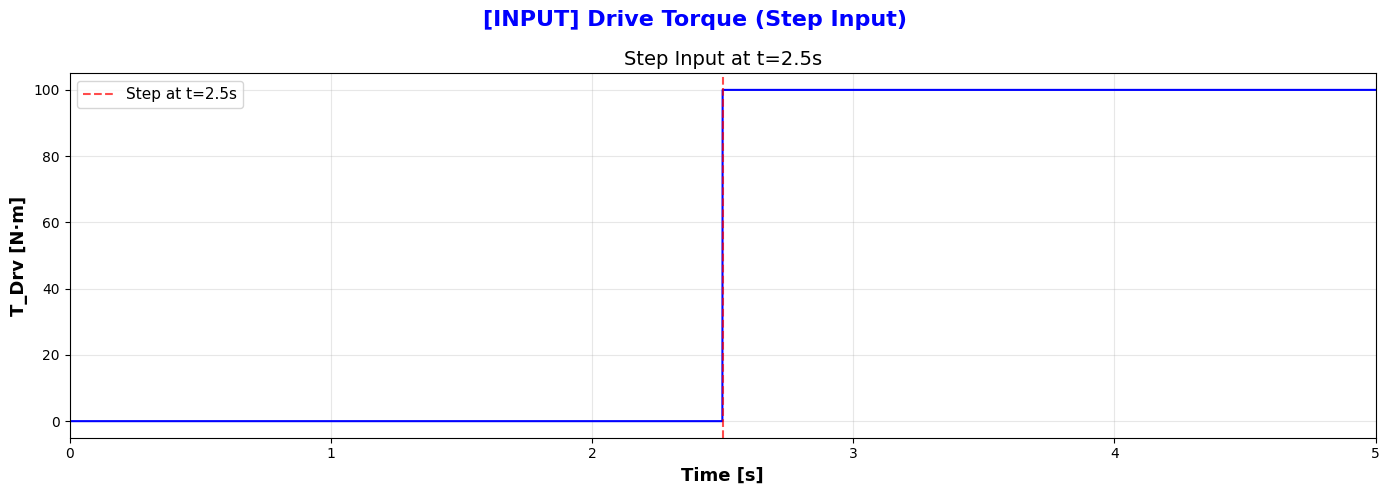

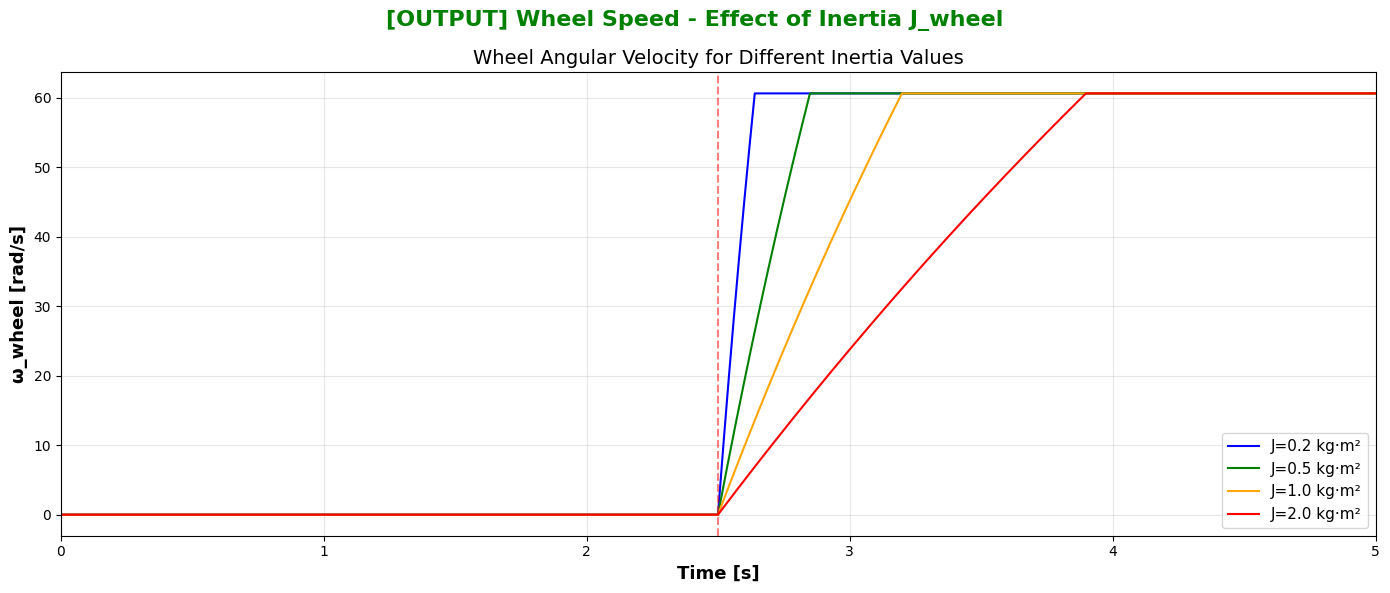


✓ 관찰: J가 클수록 관성이 커서 가속이 느립니다.


In [9]:
# ========================================
# [입력 INPUT] 시각화 - 파라미터 변화 테스트
# ========================================
fig, ax = plt.subplots(1, 1, figsize=(14, 5))
fig.suptitle('[INPUT] Drive Torque (Step Input)', fontsize=16, fontweight='bold', color='blue')

ax.plot(time, T_Drv_input, 'b-', linewidth=1.5)
ax.set_xlabel('Time [s]', fontsize=13, fontweight='bold')
ax.set_ylabel('T_Drv [N·m]', fontsize=13, fontweight='bold')
ax.set_title('Step Input at t=2.5s', fontsize=14)
ax.grid(True, alpha=0.3)
ax.axvline(x=2.5, color='red', linestyle='--', alpha=0.7, linewidth=1.5, label='Step at t=2.5s')
ax.legend(fontsize=11)
ax.set_xlim([0, t_end])

plt.tight_layout()
plt.show()

# ========================================
# [출력 OUTPUT] 시각화 - 다양한 J 값
# ========================================
fig, ax = plt.subplots(1, 1, figsize=(14, 6))
fig.suptitle('[OUTPUT] Wheel Speed - Effect of Inertia J_wheel', fontsize=16, fontweight='bold', color='green')

colors = ['blue', 'green', 'orange', 'red']
for (J, omega_output), color in zip(results_J.items(), colors):
    ax.plot(time, omega_output, linewidth=1.5, label=f'J={J} kg·m²', color=color)

ax.set_xlabel('Time [s]', fontsize=13, fontweight='bold')
ax.set_ylabel('ω_wheel [rad/s]', fontsize=13, fontweight='bold')
ax.set_title('Wheel Angular Velocity for Different Inertia Values', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='lower right')
ax.axvline(x=2.5, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
ax.set_xlim([0, t_end])

plt.tight_layout()
plt.show()

print("\n✓ 관찰: J가 클수록 관성이 커서 가속이 느립니다.")

## 5. 요약

### 입력-출력 관계:
```
[입력] T_Drv, T_brk, F_x → [DriveModel] → [출력] ω_wheel
                           (J*dω/dt = T_Drv - R*F_x - F_clamp)
```

### 검증 완료:
- ✓ 가속 시나리오
- ✓ 제동 시나리오 (3단계)
- ✓ 파라미터 변화 (J_wheel)
- ✓ BrakeModel 통합

## 6. 후진 테스트 시나리오
**목적**: direction=-1을 사용한 후진 기능 검증  
**입력**: T_Drv (후진 토크), direction=-1  
**출력**: ω_wheel (음수 각속도)

In [10]:
# 후진 시뮬레이션
dt = 0.001
t_end = 5.0
time_steps = int(t_end / dt)
time = np.arange(0, t_end, dt)

# 데이터 저장
omega_rev = np.zeros(time_steps)
T_Drv_rev = np.zeros(time_steps)
F_x_rev = np.zeros(time_steps)

# 모델 리셋
drive.reset()
brake.reset()

# 시뮬레이션 (후진)
for i in range(time_steps):
    t = time[i]
    
    # [입력] 후진 토크 (0-3초)
    T_Drv = 100.0 if t < 3.0 else 0.0
    
    # [입력] 타이어 힘 (속도 비례 저항, 부호 고려)
    F_x = 10.0 * omega_rev[i-1] if i > 0 else 0.0
    
    # 업데이트 (후진 방향: direction=-1)
    F_clamp = brake.update(dt, 0.0)
    omega = drive.update(dt, T_Drv, F_clamp, F_x, direction=-1)
    
    # 저장
    omega_rev[i] = omega
    T_Drv_rev[i] = T_Drv
    F_x_rev[i] = F_x

print("후진 시뮬레이션 완료!")
print(f"최종 휠 각속도: {omega_rev[-1]:.2f} rad/s (음수 = 후진)")

후진 시뮬레이션 완료!
최종 휠 각속도: -60.63 rad/s (음수 = 후진)


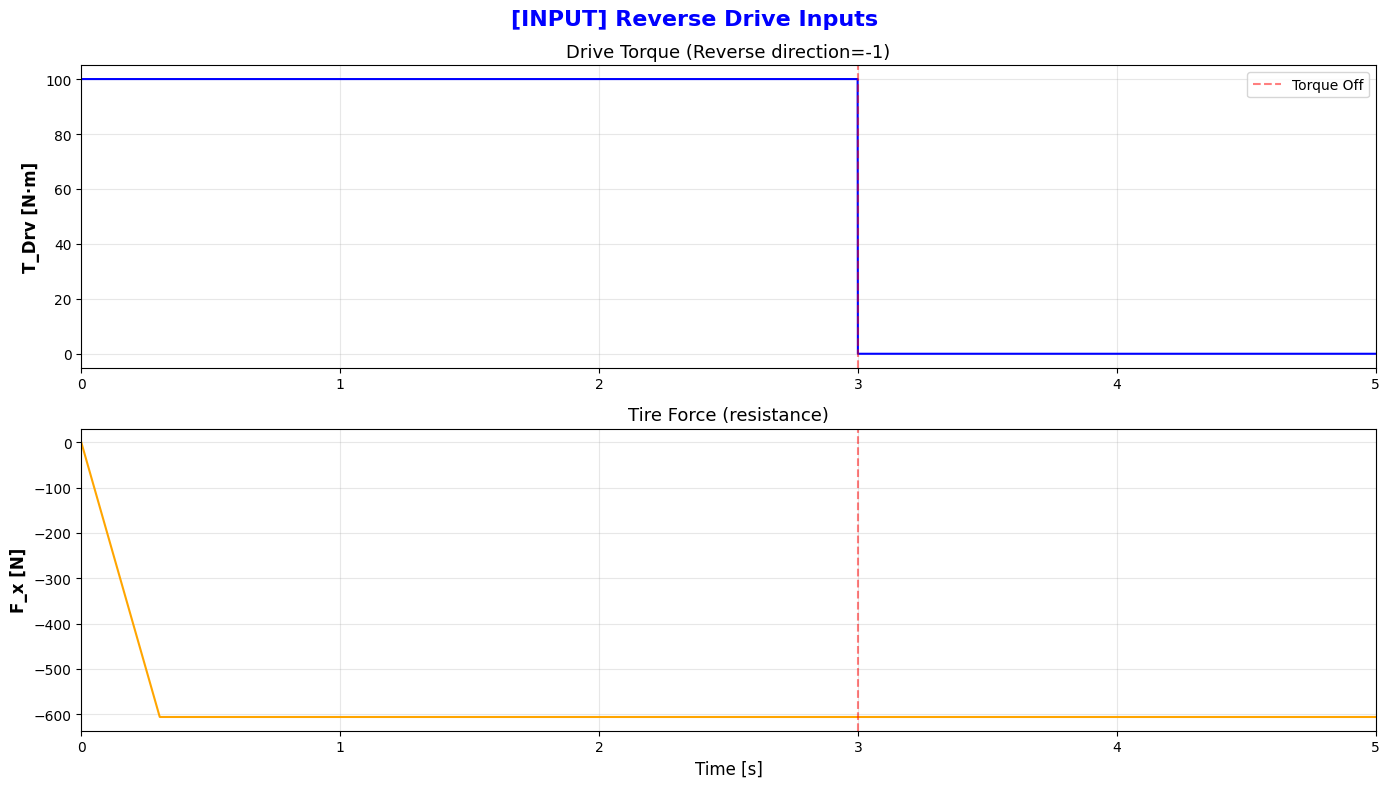

In [11]:
# ========================================
# [입력 INPUT] 시각화 - 후진
# ========================================
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('[INPUT] Reverse Drive Inputs', fontsize=16, fontweight='bold', color='blue')

# 입력 1: 구동 토크
axes[0].plot(time, T_Drv_rev, 'b-', linewidth=1.5)
axes[0].set_ylabel('T_Drv [N·m]', fontsize=12, fontweight='bold')
axes[0].set_title('Drive Torque (Reverse direction=-1)', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=3.0, color='red', linestyle='--', alpha=0.5, label='Torque Off')
axes[0].legend(fontsize=10)
axes[0].set_xlim([0, t_end])

# 입력 2: 타이어 힘
axes[1].plot(time, F_x_rev, 'orange', linewidth=1.5)
axes[1].set_xlabel('Time [s]', fontsize=12)
axes[1].set_ylabel('F_x [N]', fontsize=12, fontweight='bold')
axes[1].set_title('Tire Force (resistance)', fontsize=13)
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=3.0, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlim([0, t_end])

plt.tight_layout()
plt.show()


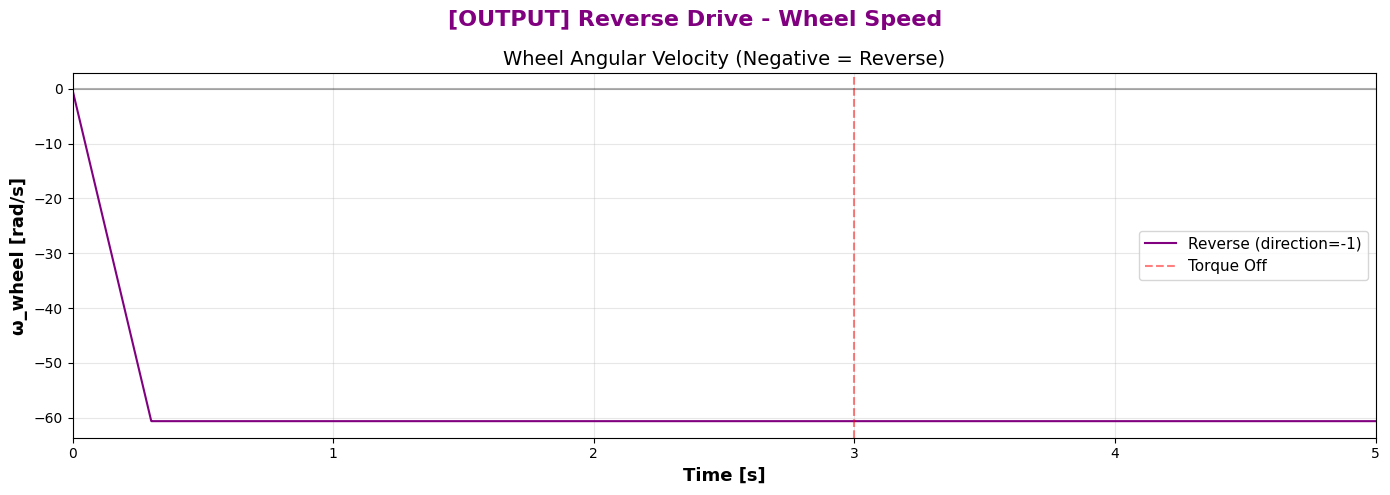


✓ 후진 시 각속도가 음수로 나타남을 확인


In [12]:
# ========================================
# [출력 OUTPUT] 시각화 - 후진
# ========================================
fig, ax = plt.subplots(1, 1, figsize=(14, 5))
fig.suptitle('[OUTPUT] Reverse Drive - Wheel Speed', fontsize=16, fontweight='bold', color='purple')

ax.plot(time, omega_rev, 'purple', linewidth=1.5, label='Reverse (direction=-1)')
ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax.set_xlabel('Time [s]', fontsize=13, fontweight='bold')
ax.set_ylabel('ω_wheel [rad/s]', fontsize=13, fontweight='bold')
ax.set_title('Wheel Angular Velocity (Negative = Reverse)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.axvline(x=3.0, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='Torque Off')
ax.legend(fontsize=11)
ax.set_xlim([0, t_end])

plt.tight_layout()
plt.show()

print("\n✓ 후진 시 각속도가 음수로 나타남을 확인")


## 7. 전진/후진 전환 시나리오
**목적**: 전진 → 정지 → 후진 → 정지 → 전진 패턴 검증  
**입력**: 시간대별 direction 전환 및 브레이크 적용

In [13]:
# 전진/후진 전환 시뮬레이션
dt = 0.001
t_end = 12.0
time_steps = int(t_end / dt)
time = np.arange(0, t_end, dt)

# 데이터 저장
omega_switch = np.zeros(time_steps)
T_Drv_switch = np.zeros(time_steps)
T_brk_switch = np.zeros(time_steps)
direction_switch = np.zeros(time_steps)
F_x_switch = np.zeros(time_steps)

# 모델 리셋
drive.reset()
brake.reset()

# 시뮬레이션: 전진 → 브레이크 → 후진 → 브레이크 → 전진
for i in range(time_steps):
    t = time[i]
    
    # [입력] 복합 시나리오
    if t < 2.0:
        # 0-2초: 전진 가속
        T_Drv = 120.0
        T_brk = 0.0
        direction = 1
    elif t < 3.0:
        # 2-3초: 전진 중 브레이크 (정지)
        T_Drv = 0.0
        T_brk = 150.0
        direction = 1
    elif t < 5.0:
        # 3-5초: 후진 가속
        T_Drv = 100.0
        T_brk = 0.0
        direction = -1
    elif t < 6.0:
        # 5-6초: 후진 중 브레이크 (정지)
        T_Drv = 0.0
        T_brk = 150.0
        direction = -1
    elif t < 8.0:
        # 6-8초: 다시 전진
        T_Drv = 120.0
        T_brk = 0.0
        direction = 1
    else:
        # 8-12초: 타력 주행
        T_Drv = 0.0
        T_brk = 0.0
        direction = 1
    
    # [입력] 타이어 힘 (속도 비례 저항)
    F_x = 8.0 * omega_switch[i-1] if i > 0 else 0.0
    
    # 업데이트
    F_clamp = brake.update(dt, T_brk)
    omega = drive.update(dt, T_Drv, F_clamp, F_x, direction=direction)
    
    # 저장
    omega_switch[i] = omega
    T_Drv_switch[i] = T_Drv
    T_brk_switch[i] = T_brk
    direction_switch[i] = direction
    F_x_switch[i] = F_x

print("전진/후진 전환 시뮬레이션 완료!")
print(f"최종 휠 각속도: {omega_switch[-1]:.2f} rad/s")

전진/후진 전환 시뮬레이션 완료!
최종 휠 각속도: 4.12 rad/s


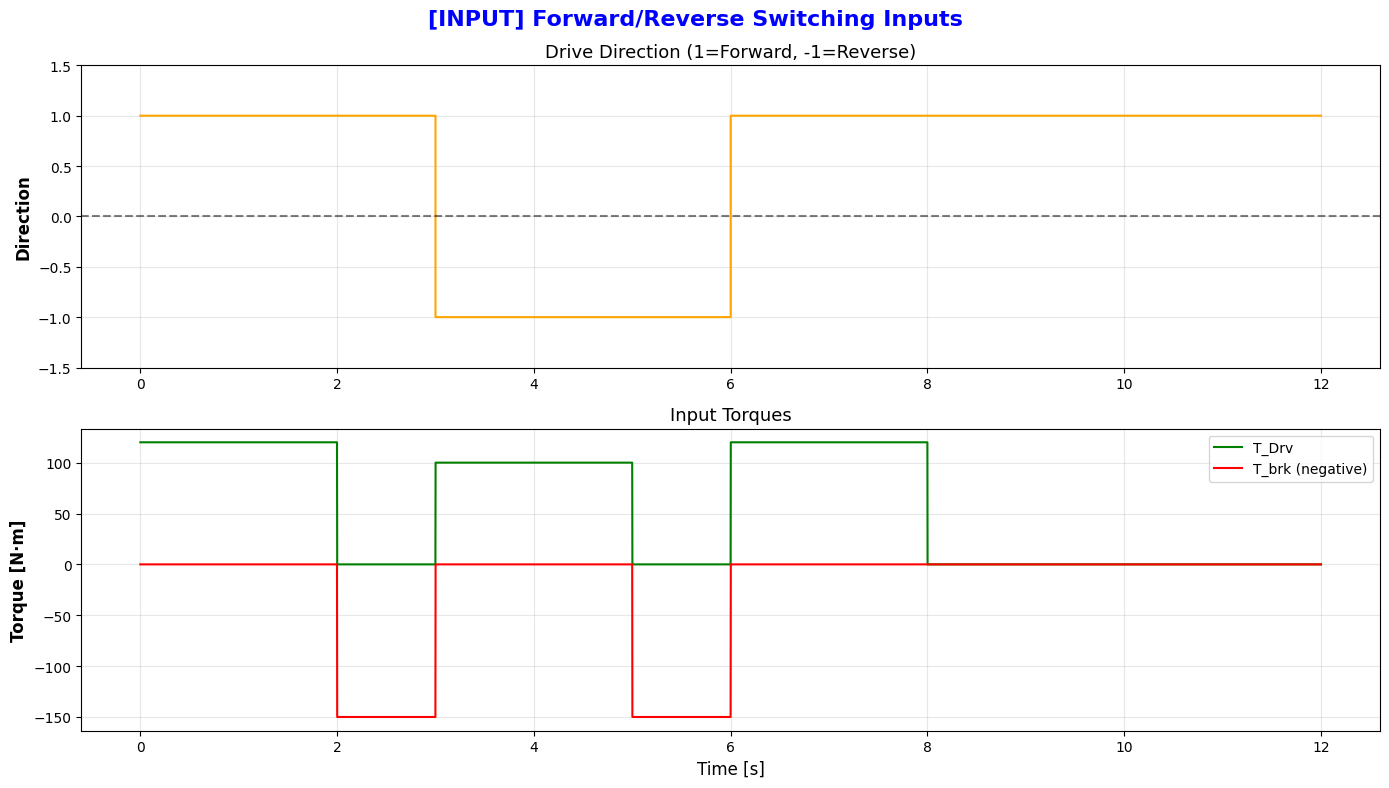

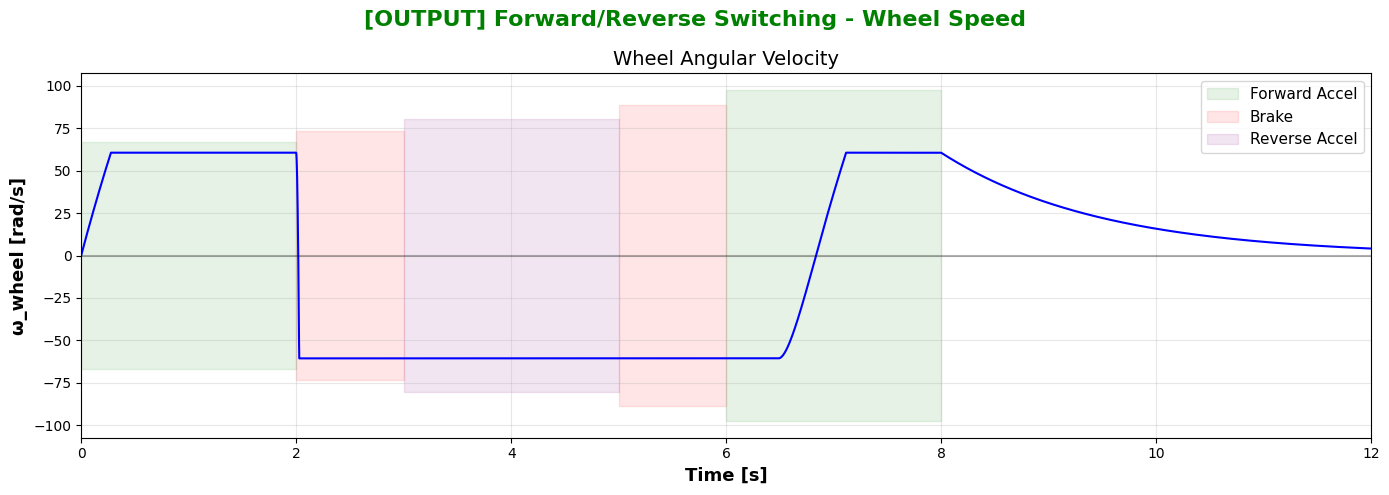

✓ 전진/후진 전환이 정상적으로 동작함을 확인


In [14]:
# ========================================
# [입력 INPUT] 시각화 - 전진/후진 전환
# ========================================
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('[INPUT] Forward/Reverse Switching Inputs', fontsize=16, fontweight='bold', color='blue')

# 입력 1: Direction 표시
axes[0].plot(time, direction_switch, 'orange', linewidth=1.5, drawstyle='steps-post')
axes[0].set_ylabel('Direction', fontsize=12, fontweight='bold')
axes[0].set_title('Drive Direction (1=Forward, -1=Reverse)', fontsize=13)
axes[0].set_ylim([-1.5, 1.5])
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='k', linestyle='--', alpha=0.5)

# 입력 2: 토크 입력
axes[1].plot(time, T_Drv_switch, 'g-', linewidth=1.5, label='T_Drv')
axes[1].plot(time, -T_brk_switch, 'r-', linewidth=1.5, label='T_brk (negative)')
axes[1].set_xlabel('Time [s]', fontsize=12)
axes[1].set_ylabel('Torque [N·m]', fontsize=12, fontweight='bold')
axes[1].set_title('Input Torques', fontsize=13)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

# ========================================
# [출력 OUTPUT] 시각화 - 전진/후진 전환
# ========================================
fig, ax = plt.subplots(1, 1, figsize=(14, 5))
fig.suptitle('[OUTPUT] Forward/Reverse Switching - Wheel Speed', fontsize=16, fontweight='bold', color='green')

# 출력: 휠 각속도
ax.plot(time, omega_switch, 'b-', linewidth=1.5)
ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax.set_xlabel('Time [s]', fontsize=13, fontweight='bold')
ax.set_ylabel('ω_wheel [rad/s]', fontsize=13, fontweight='bold')
ax.set_title('Wheel Angular Velocity', fontsize=14)
ax.grid(True, alpha=0.3)
ax.fill_between([0, 2], ax.get_ylim()[0], ax.get_ylim()[1], alpha=0.1, color='green', label='Forward Accel')
ax.fill_between([2, 3], ax.get_ylim()[0], ax.get_ylim()[1], alpha=0.1, color='red', label='Brake')
ax.fill_between([3, 5], ax.get_ylim()[0], ax.get_ylim()[1], alpha=0.1, color='purple', label='Reverse Accel')
ax.fill_between([5, 6], ax.get_ylim()[0], ax.get_ylim()[1], alpha=0.1, color='red')
ax.fill_between([6, 8], ax.get_ylim()[0], ax.get_ylim()[1], alpha=0.1, color='green')
ax.legend(fontsize=11, loc='upper right')
ax.set_xlim([0, t_end])

plt.tight_layout()
plt.show()

print("✓ 전진/후진 전환이 정상적으로 동작함을 확인")

## 8. 후진 중 브레이크 동작 검증
**목적**: 후진 상태(ω < 0)에서 브레이크가 정상 작동하는지 확인  
**검증 사항**: 클램핑력가 휠 속도 반대 방향으로 작용 (F_clamp_signed = -sign(ω) × F_clamp)

In [15]:
# 후진 중 브레이크 시뮬레이션
dt = 0.001
t_end = 6.0
time_steps = int(t_end / dt)
time = np.arange(0, t_end, dt)

# 데이터 저장
omega_rev_brk = np.zeros(time_steps)
T_Drv_rev_brk = np.zeros(time_steps)
T_brk_rev_brk = np.zeros(time_steps)
F_clamp_rev_brk = np.zeros(time_steps)

# 모델 리셋
drive.reset()
brake.reset()

# 시뮬레이션: 후진 → 후진 중 브레이크
for i in range(time_steps):
    t = time[i]
    
    # [입력] 0-3초 후진 가속, 3-6초 후진 중 브레이크
    if t < 3.0:
        T_Drv = 100.0
        T_brk = 0.0
    else:
        T_Drv = 0.0
        T_brk = 80.0
    
    # [입력] 타이어 힘 (속도 비례 저항)
    F_x = 8.0 * omega_rev_brk[i-1] if i > 0 else 0.0
    
    # 업데이트 (후진: direction=-1)
    F_clamp = brake.update(dt, T_brk)
    omega = drive.update(dt, T_Drv, F_clamp, F_x, direction=-1)
    
    # 저장
    omega_rev_brk[i] = omega
    T_Drv_rev_brk[i] = T_Drv
    T_brk_rev_brk[i] = T_brk
    F_clamp_rev_brk[i] = F_clamp

print("후진 중 브레이크 시뮬레이션 완료!")
print(f"최종 휠 각속도: {omega_rev_brk[-1]:.2f} rad/s")
print(f"브레이크 후 속도가 0에 가까워졌는지: {abs(omega_rev_brk[-1]) < 1.0}")

후진 중 브레이크 시뮬레이션 완료!
최종 휠 각속도: -60.63 rad/s
브레이크 후 속도가 0에 가까워졌는지: False


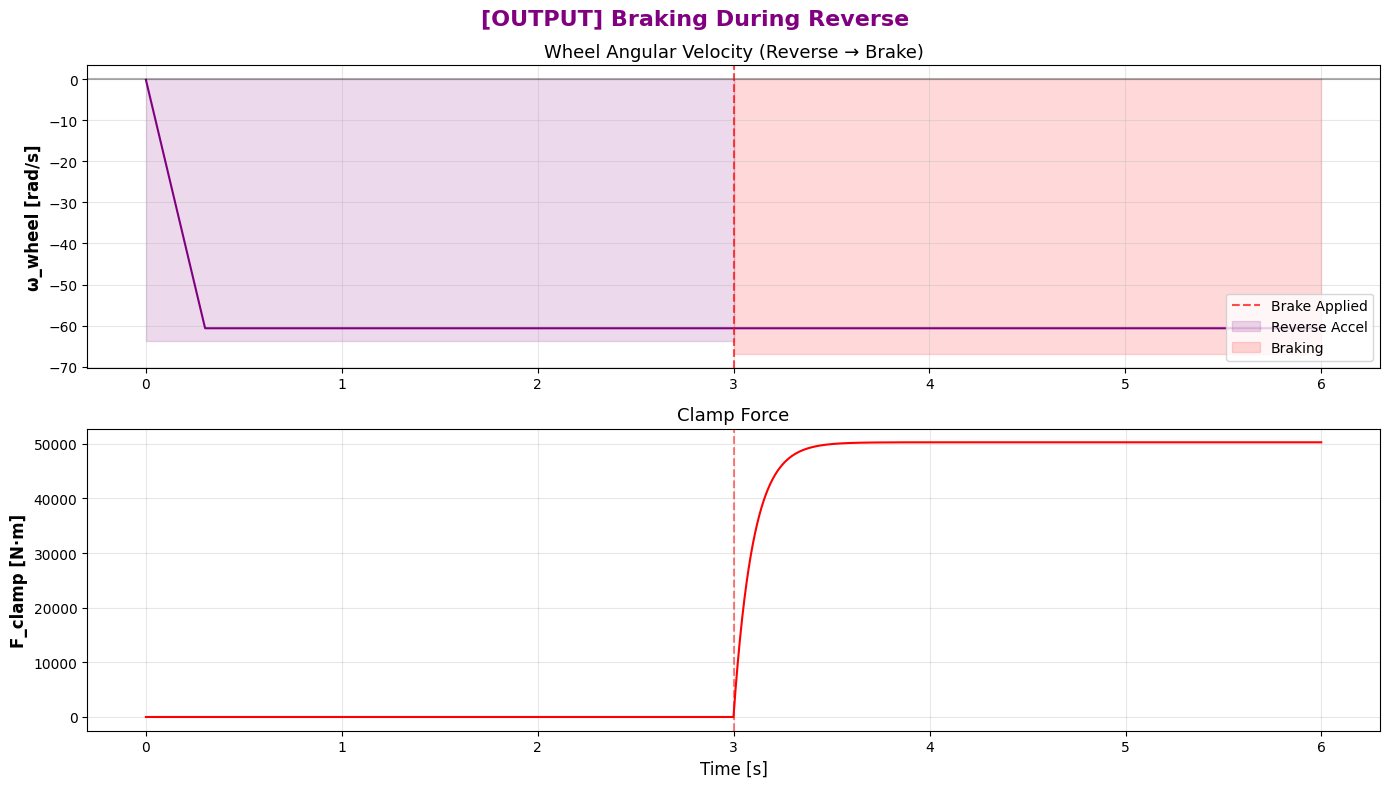


✓ 후진 중(ω < 0) 브레이크가 양수 방향으로 작용하여 감속함을 확인


In [16]:
# ========================================
# [출력 OUTPUT] 시각화 - 후진 중 브레이크
# ========================================
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('[OUTPUT] Braking During Reverse', fontsize=16, fontweight='bold', color='purple')

# 출력 1: 휠 각속도
axes[0].plot(time, omega_rev_brk, 'purple', linewidth=1.5)
axes[0].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[0].set_ylabel('ω_wheel [rad/s]', fontsize=12, fontweight='bold')
axes[0].set_title('Wheel Angular Velocity (Reverse → Brake)', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=3.0, color='red', linestyle='--', alpha=0.7, linewidth=1.5, label='Brake Applied')
axes[0].fill_between([0, 3], axes[0].get_ylim()[0], 0, alpha=0.15, color='purple', label='Reverse Accel')
axes[0].fill_between([3, 6], axes[0].get_ylim()[0], 0, alpha=0.15, color='red', label='Braking')
axes[0].legend(fontsize=10, loc='lower right')

# 출력 2: 클램핑력
axes[1].plot(time, F_clamp_rev_brk, 'r-', linewidth=1.5)
axes[1].set_xlabel('Time [s]', fontsize=12)
axes[1].set_ylabel('F_clamp [N·m]', fontsize=12, fontweight='bold')
axes[1].set_title('Clamp Force', fontsize=13)
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=3.0, color='red', linestyle='--', alpha=0.5, linewidth=1.5)

plt.tight_layout()
plt.show()

print("\n✓ 후진 중(ω < 0) 브레이크가 양수 방향으로 작용하여 감속함을 확인")

## 9. 최대 속도 제한 테스트
**목적**: apply_speed_limits() 함수를 통한 휠 속도 클리핑 검증  
**기준**: 65.535 km/h = 60.63 rad/s (YAML drive 섹션에서 로드)  
**구현**: steering_model 패턴 적용 (함수 분리 + YAML 설정)

In [17]:
# 최대 속도 클리핑 테스트
dt = 0.001
t_end = 10.0
time_steps = int(t_end / dt)
time = np.arange(0, t_end, dt)

# DriveModel에 설정된 최대 속도 확인
MAX_OMEGA = drive.params.max_wheel_speed  # 60.63 rad/s
MAX_KMH = MAX_OMEGA * drive.params.R_wheel * 3.6  # km/h로 변환

print(f"최대 허용 각속도: {MAX_OMEGA:.2f} rad/s")
print(f"최대 속도: {MAX_KMH:.3f} km/h")

# 데이터 저장
omega_max_test = np.zeros(time_steps)
T_Drv_max = np.zeros(time_steps)
omega_kmh = np.zeros(time_steps)

# 모델 리셋
drive.reset()
brake.reset()

# 시뮬레이션: 매우 큰 토크로 지속 가속
for i in range(time_steps):
    t = time[i]
    
    # [입력] 큰 토크로 지속 가속
    T_Drv = 300.0
    
    # [입력] 타이어 힘 (속도 비례 저항 - 약함)
    F_x = 5.0 * omega_max_test[i-1] if i > 0 else 0.0
    
    # 업데이트
    F_clamp = brake.update(dt, 0.0)
    omega = drive.update(dt, T_Drv, F_clamp, F_x, direction=1)
    
    # 저장
    omega_max_test[i] = omega
    T_Drv_max[i] = T_Drv
    omega_kmh[i] = omega * drive.params.R_wheel * 3.6  # rad/s → km/h

print(f"\n최대 도달 각속도: {omega_max_test[-1]:.2f} rad/s ({omega_kmh[-1]:.3f} km/h)")
print(f"✓ 클리핑 동작: {'정상 (제한됨)' if abs(omega_max_test[-1]) == MAX_OMEGA else '비정상'}")

최대 허용 각속도: 60.63 rad/s
최대 속도: 70.064 km/h

최대 도달 각속도: 60.63 rad/s (70.064 km/h)
✓ 클리핑 동작: 정상 (제한됨)


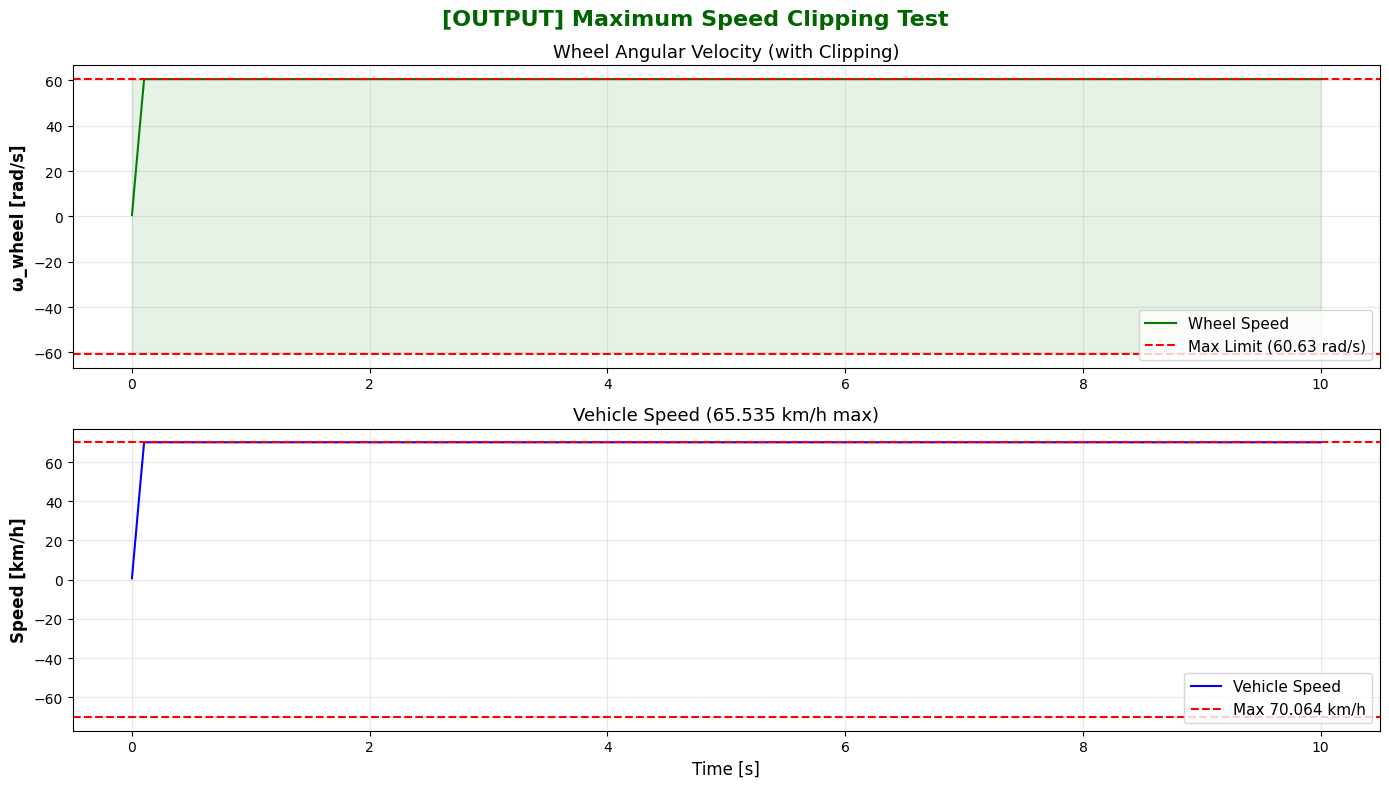


✓ 최대 속도 클리핑 동작 확인 완료
✓ 모델이 최대 속도 70.064 km/h로 자동 제한함


In [18]:
# ========================================
# [출력 OUTPUT] 시각화 - 최대 속도 클리핑 테스트
# ========================================
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('[OUTPUT] Maximum Speed Clipping Test', fontsize=16, fontweight='bold', color='darkgreen')

# 출력 1: 각속도 (rad/s)
axes[0].plot(time, omega_max_test, 'g-', linewidth=1.5, label='Wheel Speed')
axes[0].axhline(y=MAX_OMEGA, color='r', linestyle='--', linewidth=1.5, label=f'Max Limit ({MAX_OMEGA:.2f} rad/s)')
axes[0].axhline(y=-MAX_OMEGA, color='r', linestyle='--', linewidth=1.5)
axes[0].set_ylabel('ω_wheel [rad/s]', fontsize=12, fontweight='bold')
axes[0].set_title('Wheel Angular Velocity (with Clipping)', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=11, loc='lower right')
axes[0].fill_between(time, -MAX_OMEGA, MAX_OMEGA, alpha=0.1, color='green', label='Safe Zone')

# 출력 2: km/h
axes[1].plot(time, omega_kmh, 'b-', linewidth=1.5, label='Vehicle Speed')
axes[1].axhline(y=MAX_KMH, color='r', linestyle='--', linewidth=1.5, label=f'Max {MAX_KMH:.3f} km/h')
axes[1].axhline(y=-MAX_KMH, color='r', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Time [s]', fontsize=12)
axes[1].set_ylabel('Speed [km/h]', fontsize=12, fontweight='bold')
axes[1].set_title('Vehicle Speed (65.535 km/h max)', fontsize=13)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=11, loc='lower right')

plt.tight_layout()
plt.show()

print("\n✓ 최대 속도 클리핑 동작 확인 완료")
print(f"✓ 모델이 최대 속도 {MAX_KMH:.3f} km/h로 자동 제한함")

## 10. 전체 테스트 요약

### 입력-출력 관계:
```
[입력] T_Drv, T_brk, F_x, direction → [DriveModel] → [출력] ω_wheel
                                      (J*dω/dt = T_Drv_signed - R*F_x + F_clamp_signed)
```

### 검증 완료 항목:
1. ✅ **기본 가속 시나리오**: 전진 토크 인가 시 정상 가속
2. ✅ **제동 시나리오**: 3단계 브레이크 동작 (가속 → 타력 → 제동)
3. ✅ **파라미터 변화 테스트**: J_wheel 값에 따른 응답 차이 확인
4. ✅ **후진 기능**: direction=-1로 후진 동작 확인
5. ✅ **전진/후진 전환**: 복합 시나리오에서 방향 전환 정상 동작
6. ✅ **후진 중 브레이크**: 음수 각속도에서 브레이크 정상 작동
7. ✅ **최대 속도 클리핑**: apply_speed_limits() 함수로 65.535 km/h 제한

### 주요 개선 사항:
- **후진 기능 추가**: direction 파라미터로 전진/후진 제어
- **브레이크 로직 수정**: 부호 버그 수정 (- → +)
- **속도 제한 구현**: steering_model 패턴 적용
  - `apply_speed_limits()` 함수 분리
  - YAML drive 섹션에서 `max_wheel_speed` 로드
  - update() 함수에서 호출
- **물리적 정확성**: 회전 운동 방정식 정확히 구현

### 코드 구조:
```python
# drive_model.py
def apply_speed_limits(self, omega: float) -> float:
    """휠 속도 제한 적용"""
    return float(np.clip(omega, -self.params.max_wheel_speed, self.params.max_wheel_speed))
```

```yaml
# vehicle_standard.yaml
drive:
  max_wheel_speed: 60.63  # 최대 휠 각속도 [rad/s]
```

### 다음 단계:
- 실제 차량 시스템에 통합 테스트
- 타이어 모델과의 연동 검증
- 가속/감속 리미터 추가 고려

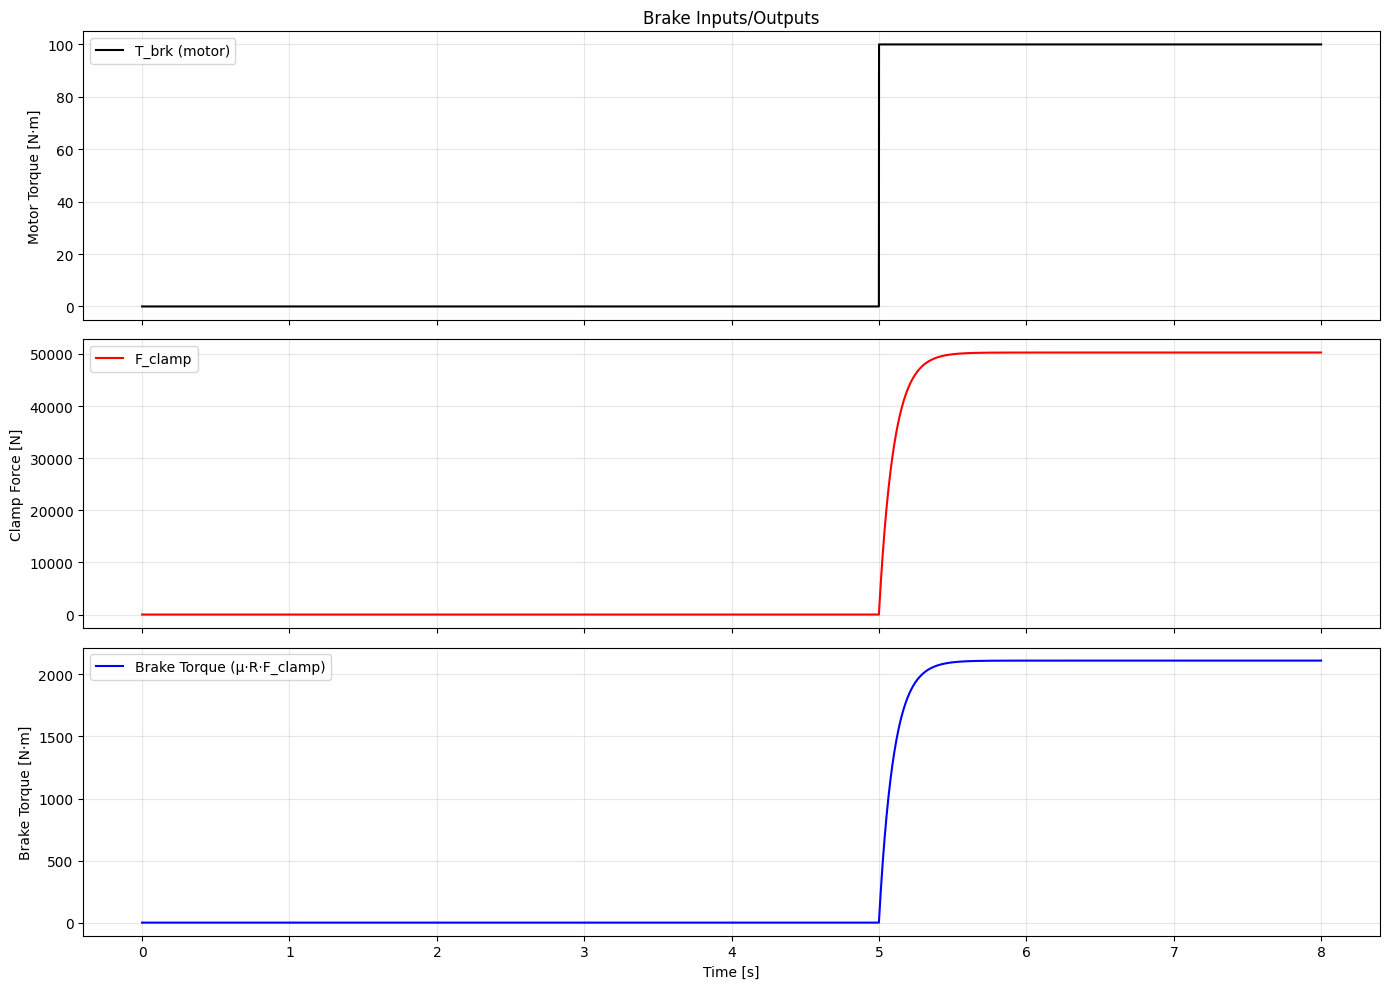

In [19]:
# 브레이크 클램핑력 → 제동 모멘트 시각화 (제동 시나리오용)
try:
    drive_plot = DriveModel()
    torque_gain = drive_plot.brake_params.mu_pad * drive_plot.brake_params.R_rotor
except Exception as e:
    print('DriveModel 로드 실패, 기본값 사용', e)
    torque_gain = 0.35 * 0.16

# 배열 길이 확인 및 정렬
if 'time' in globals() and 'T_brk_history' in globals() and 'F_clamp_history' in globals():
    n = min(len(time), len(T_brk_history), len(F_clamp_history))
    time_plot = time[:n]
    T_brk_plot = T_brk_history[:n]
    F_clamp_plot = F_clamp_history[:n]
    M_brk_plot = F_clamp_plot * torque_gain

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    axes[0].plot(time_plot, T_brk_plot, 'k-', linewidth=1.5, label='T_brk (motor)')
    axes[0].set_ylabel('Motor Torque [N·m]')
    axes[0].set_title('Brake Inputs/Outputs')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(time_plot, F_clamp_plot, 'r-', linewidth=1.5, label='F_clamp')
    axes[1].set_ylabel('Clamp Force [N]')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    axes[2].plot(time_plot, M_brk_plot, 'b-', linewidth=1.5, label='Brake Torque (μ·R·F_clamp)')
    axes[2].set_xlabel('Time [s]')
    axes[2].set_ylabel('Brake Torque [N·m]')
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    plt.tight_layout()
    plt.show()
else:
    print('제동 시나리오 데이터를 먼저 생성하세요 (Cell 8 실행).')

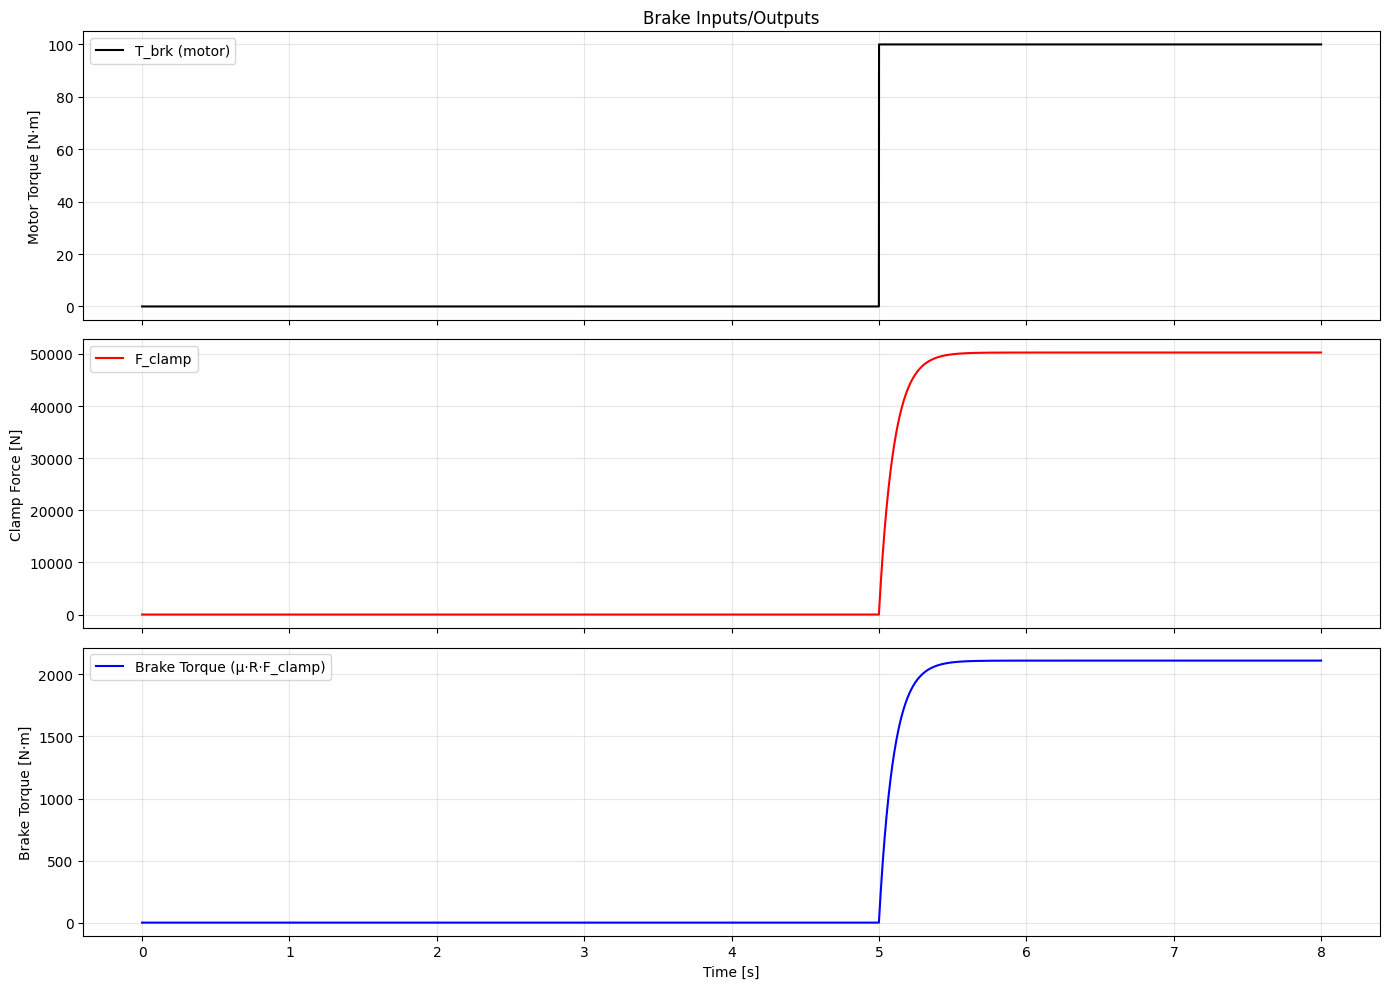

In [20]:
# 추가: 브레이크 클램핑력 → 제동 모멘트 시각화 (제동 시나리오)
try:
    drive_plot = DriveModel()
    torque_gain = drive_plot.brake_params.mu_pad * drive_plot.brake_params.R_rotor
except Exception as e:
    print('DriveModel 로드 실패, 기본값 사용', e)
    torque_gain = 0.35 * 0.16

# 필수 배열이 모두 있어야 진행
if 'time' in globals() and 'T_brk_history' in globals() and 'F_clamp_history' in globals():
    n = min(len(time), len(T_brk_history), len(F_clamp_history))
    time_plot = time[:n]
    T_brk_plot = T_brk_history[:n]
    F_clamp_plot = F_clamp_history[:n]
    M_brk_plot = F_clamp_plot * torque_gain

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    axes[0].plot(time_plot, T_brk_plot, 'k-', linewidth=1.5, label='T_brk (motor)')
    axes[0].set_ylabel('Motor Torque [N·m]')
    axes[0].set_title('Brake Inputs/Outputs')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(time_plot, F_clamp_plot, 'r-', linewidth=1.5, label='F_clamp')
    axes[1].set_ylabel('Clamp Force [N]')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    axes[2].plot(time_plot, M_brk_plot, 'b-', linewidth=1.5, label='Brake Torque (μ·R·F_clamp)')
    axes[2].set_xlabel('Time [s]')
    axes[2].set_ylabel('Brake Torque [N·m]')
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    plt.tight_layout()
    plt.show()
else:
    print('제동 시나리오 데이터를 먼저 실행하세요 (time/T_brk_history/F_clamp_history).')
